Using device: cuda
torch.Size([300, 300])


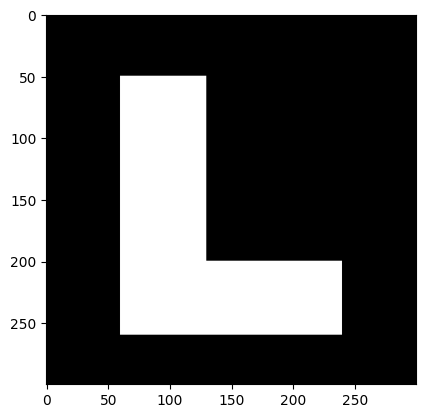

torch.Size([300, 300])


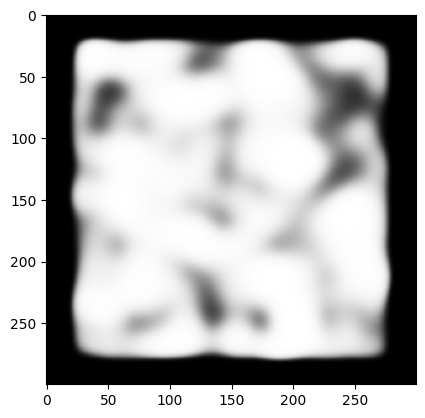

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import cv2


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

target = Image.open(r'C:\Users\MelvinTheArch\Desktop\Research\Pytorch from scratch\\Lshape.png').convert('L')
target = np.array(target)
target = torch.tensor(target, dtype=torch.float32, device=device)
H, W = target.shape
print(target.shape)

target_binary = (target > 125).float()
plt.imshow(target_binary.detach().cpu().numpy(), cmap='gray')
plt.show()

mask = torch.nn.Parameter(torch.rand(H, W, device=device) * 255)
print(mask.shape)

# adding gausssian blurring
kernel_size = 77
sigma = 0.3 * (kernel_size / 2 - 1) + 0.8
g_kernel = cv2.getGaussianKernel(kernel_size, sigma)
g_kernel = g_kernel @ g_kernel.T
g_kernel = torch.tensor(g_kernel, dtype=torch.float32, device=device).view(1, 1, kernel_size, kernel_size)

temperature = 1

#pred=F.conv2d(mask.unsqueeze(0).unsqueeze(0), g_kernel, padding=kernel_size//2)[0,0]
#pred=torch.where(pred>pred.mean()+5, 255.0, 0.0)
#print(pred.shape)
#plt.imshow(pred.detach().numpy())
#pred=torch.nn.Parameter(pred)
blur_image = F.conv2d(mask.unsqueeze(0).unsqueeze(0), g_kernel, padding=kernel_size // 2)[0, 0]
soft_cure = torch.sigmoid((blur_image - 125.0) / temperature)
#plt.imshow(blur_image.detach().numpy(), cmap='gray')
#plt.show()
plt.imshow(soft_cure.detach().cpu().numpy(), cmap='gray')
plt.show()


Epoch 0, Loss: 0.3543056845664978


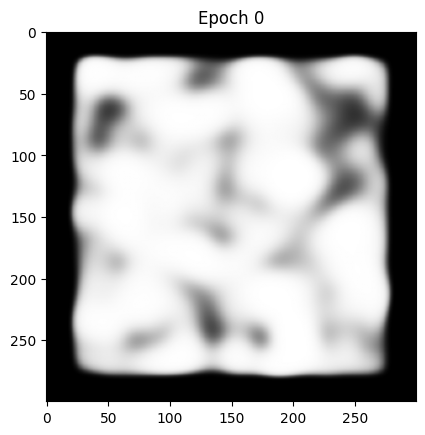

Epoch 100, Loss: 0.046049993485212326


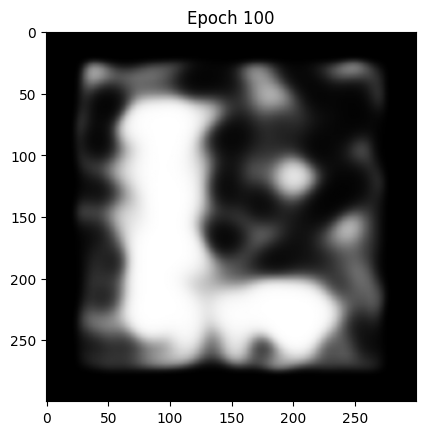

Epoch 200, Loss: 0.016371343284845352


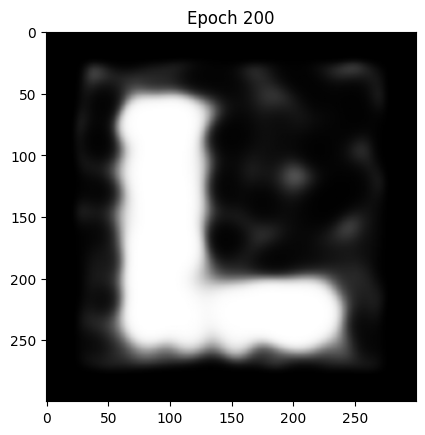

Epoch 300, Loss: 0.011988637037575245


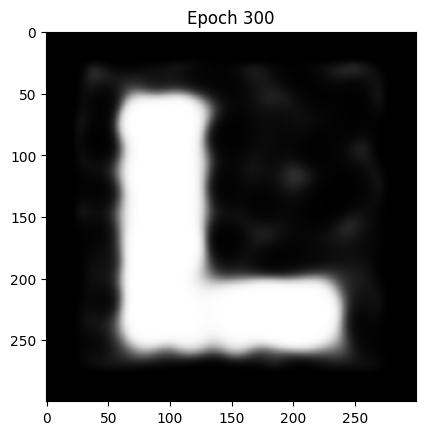

Epoch 400, Loss: 0.009975606575608253


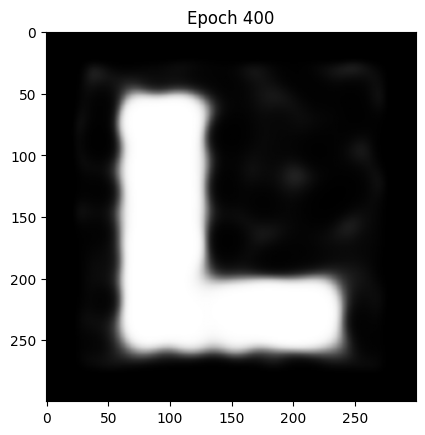

Epoch 500, Loss: 0.008753085508942604


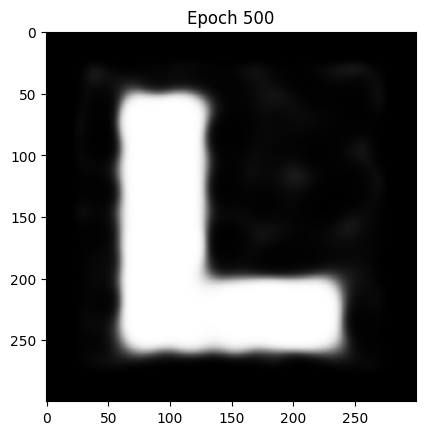

Epoch 600, Loss: 0.00790473259985447


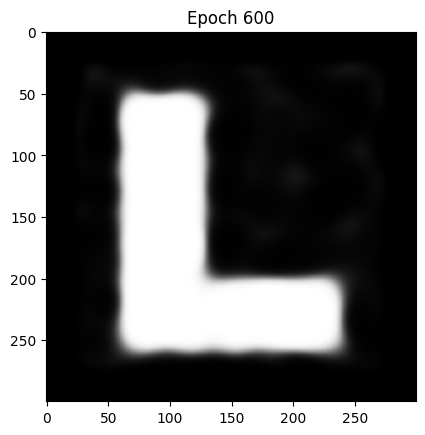

Epoch 700, Loss: 0.007268210407346487


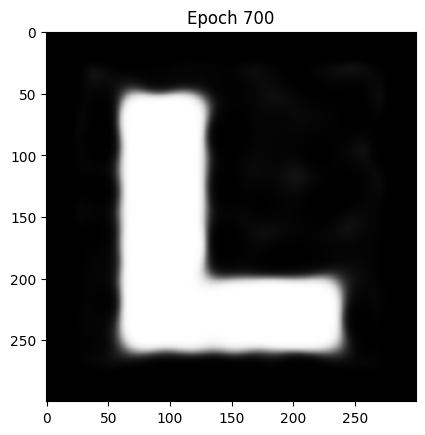

Epoch 800, Loss: 0.006766003556549549


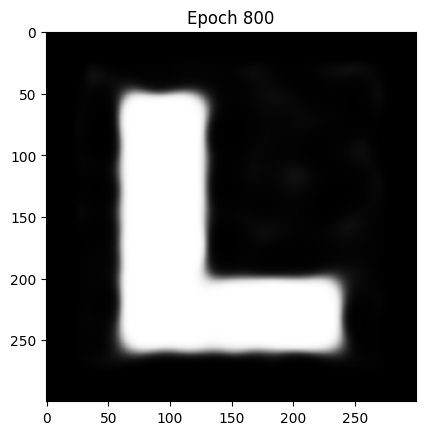

Epoch 900, Loss: 0.0063554211519658566


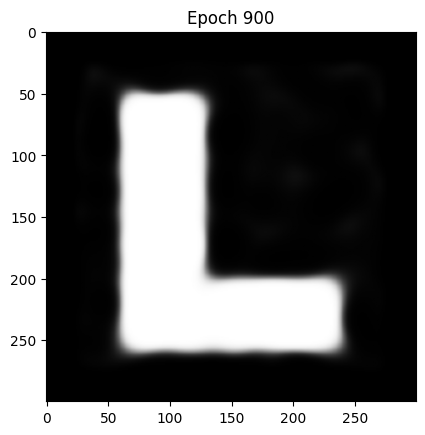

Epoch 1000, Loss: 0.0060105216689407825


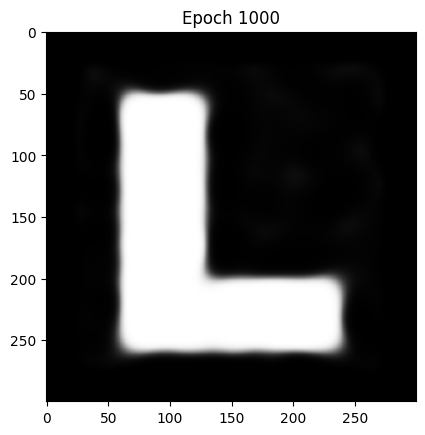

Epoch 1100, Loss: 0.005714694503694773


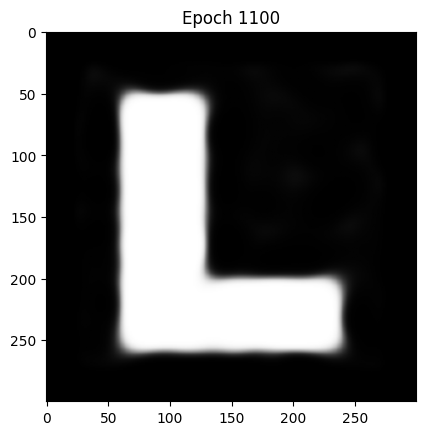

Epoch 1200, Loss: 0.005456486251205206


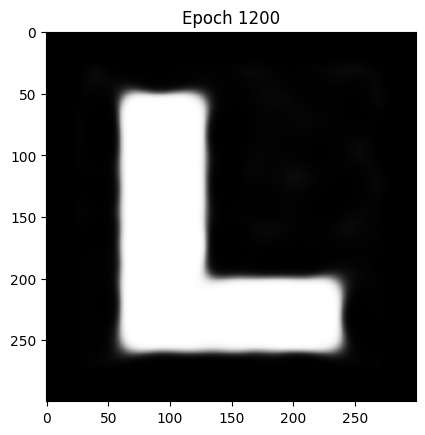

Epoch 1300, Loss: 0.005228162743151188


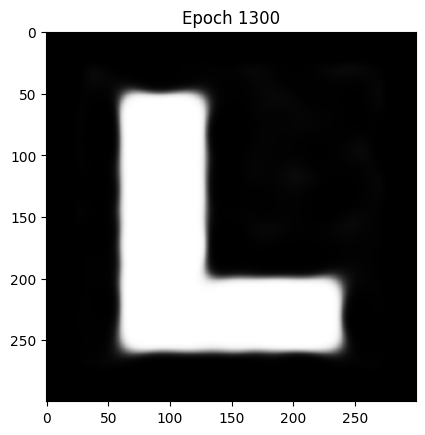

Epoch 1400, Loss: 0.0050239646807312965


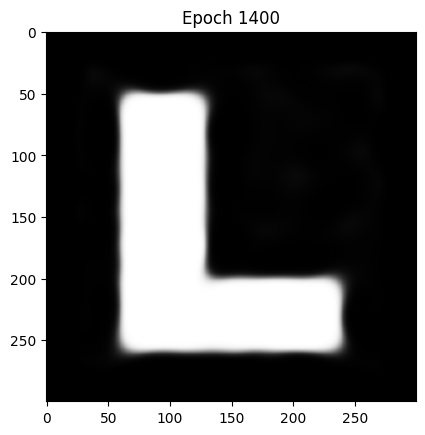

Epoch 1500, Loss: 0.0048396531492471695


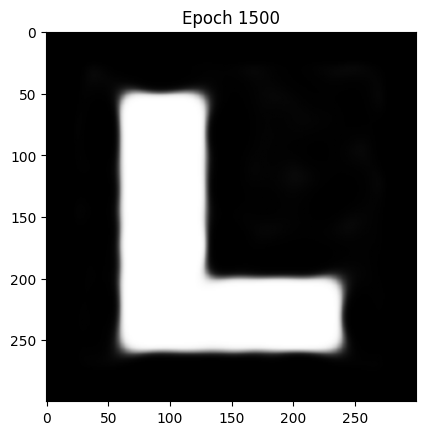

Epoch 1600, Loss: 0.00467188423499465


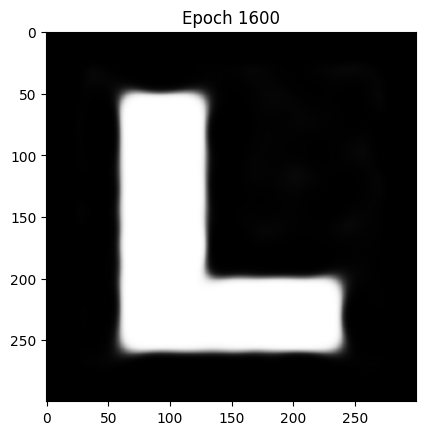

Epoch 1700, Loss: 0.004517954774200916


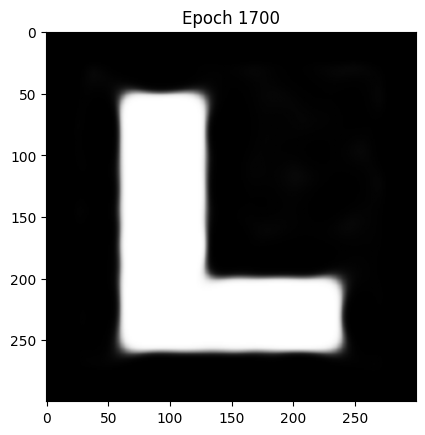

Epoch 1800, Loss: 0.00437593087553978


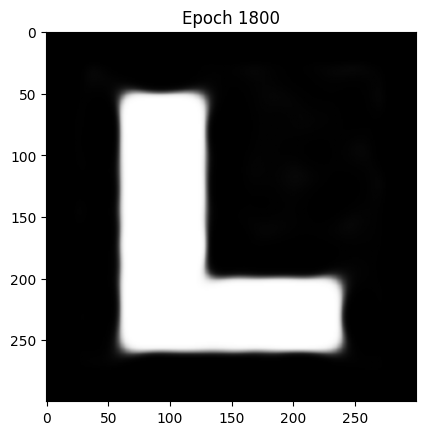

Epoch 1900, Loss: 0.004244116134941578


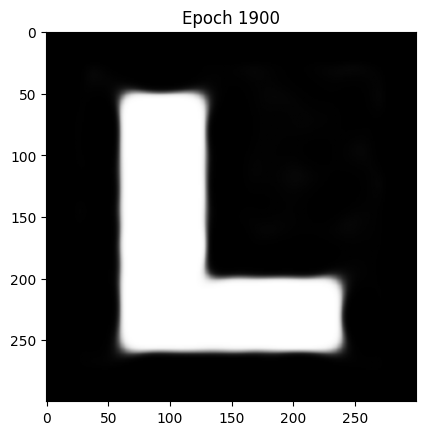

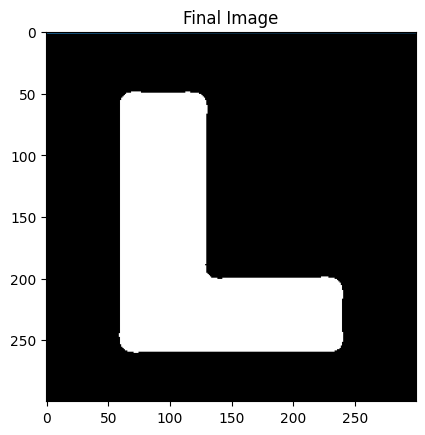

In [2]:
optimizer = torch.optim.Adam(params=[mask], lr=0.05)
loss_fn = nn.MSELoss()
epochs = 2000
loss_history = []

for epoch in range(epochs):
    blur_image = F.conv2d(mask.unsqueeze(0).unsqueeze(0), g_kernel, padding=kernel_size // 2)[0, 0]
    soft_cure = torch.sigmoid((blur_image - 125.0) / temperature)

    optimizer.zero_grad()
    loss = loss_fn(target_binary, soft_cure)
    loss_history.append(loss.item())
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        mask.clamp_(0, 255)

    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')
        inter_img = (soft_cure.detach() * 255).clamp(0, 255)
        plt.imshow(inter_img.cpu().numpy(), cmap='gray')
        plt.title(f'Epoch {epoch}')
        plt.show()

plt.plot(range(len(loss_history)), loss_history)
final_blur = F.conv2d(mask.unsqueeze(0).unsqueeze(0), g_kernel, padding=kernel_size // 2)[0, 0]
final_img = (final_blur > 125).float().detach().mul(255).cpu().numpy()
plt.imshow(final_img, cmap='gray')
plt.title('Final Image')
plt.show()
#plt.imshow(mask[0,0], cmap='gray')
#plt.show()